# Explorative Data Analysis

# _____________________________________________

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from scipy import stats

## Load Data

In [19]:
data = pd.read_parquet("data/ENTSOE/entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("data/NOAA GFS/weather_forecast.parquet")
df = data.join(weather_fc, how="left")

# only keep data from 2023-01-01 to 2025-12-31
df = df["2023":"2025"]
# only train data
df_train = df["2023":"2024"]

## Data Quality Check

In [20]:
# Ensure expected period
expected_index = pd.date_range(start="2023-01-01 00:00:00+01:00", end="2025-12-31 23:00:00+01:00", freq="h")
missing_timestamps = expected_index.difference(df.index)
extra_timestamps = df.index.difference(expected_index)

# Data quality checks
quality_checks = {
    "start": str(df.index.min()),
    "end": str(df.index.max()),
    "rows": len(df),
    "columns": len(df.columns),
    "frequency": str(pd.infer_freq(df.index)),
    "monotonic increasing": bool(df.index.is_monotonic_increasing),
    "duplicate index": bool(df.index.duplicated().any()),
    "missing rows/hours": int(len(missing_timestamps)),
    "extra rows/hours": int(len(extra_timestamps)),
    "timezone": str(df.index.tz),
    "missing values":df.isna().sum().sum(),
}

quality_df = pd.DataFrame.from_dict(quality_checks, orient="index", columns=["value"])
quality_df

,value
start,2023-01-01 00:00:00+01:00
end,2025-12-31 23:00:00+01:00
rows,26304
columns,8
frequency,h
monotonic increasing,True
duplicate index,False
missing rows/hours,0
extra rows/hours,0
timezone,Europe/Berlin


# Insights target variable `da_price` 

In [21]:
yearly = df.groupby(df.index.year)["da_price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
total = df["da_price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T
total.index = ["all data"]

display("da_price summary statistics:")
display(pd.concat([yearly, total]).round(2))

'da_price summary statistics:'

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
2023,8760.0,95.18,47.58,-500.00,-5.24,1.07,75.88,98.02,122.12,166.25,207.98,524.27
2024,8784.0,78.51,52.73,-135.45,-19.95,-0.01,55.56,79.59,101.34,143.25,224.86,936.28
2025,8760.0,89.32,52.10,-250.32,-18.89,-0.11,71.09,92.43,114.14,162.35,242.84,583.40
all data,26304.0,87.66,51.32,-500.00,-14.99,-0.01,65.06,90.06,112.97,159.90,222.07,936.28


The price series contains several large positive and negative values.

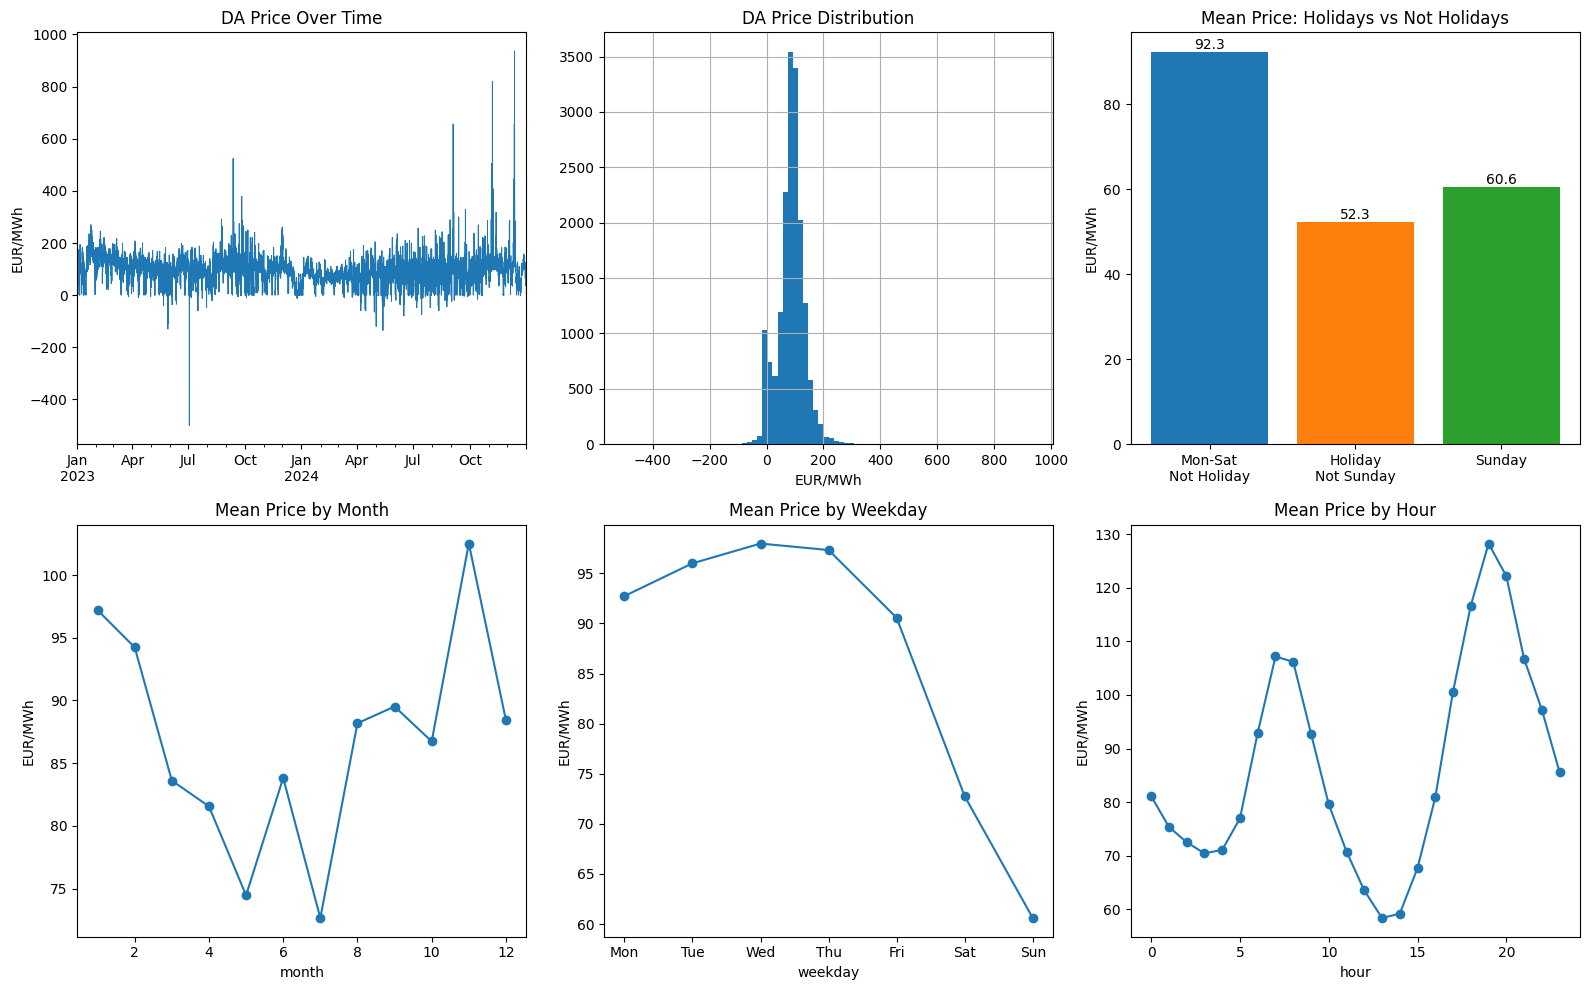

In [22]:
import holidays

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

df_train["da_price"].plot(ax=axes[0, 0], title="DA Price Over Time", linewidth=0.7)
axes[0, 0].set_ylabel("EUR/MWh")

df_train["da_price"].hist(ax=axes[0, 1], bins=80)
axes[0, 1].set_title("DA Price Distribution")
axes[0, 1].set_xlabel("EUR/MWh")

df_train.assign(month=df_train.index.month).groupby("month")["da_price"].mean().plot(ax=axes[1, 0], marker="o", title="Mean Price by Month")
axes[1, 0].set_ylabel("EUR/MWh")

df_train.assign(weekday=df_train.index.dayofweek).groupby("weekday")["da_price"].mean().plot(ax=axes[1, 1], marker="o", title="Mean Price by Weekday")
axes[1, 1].set_ylabel("EUR/MWh")
axes[1, 1].set_xticks(range(7))
axes[1, 1].set_xticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

df_train.assign(hour=df_train.index.hour).groupby("hour")["da_price"].mean().plot(ax=axes[1, 2], marker="o", title="Mean Price by Hour")
axes[1, 2].set_ylabel("EUR/MWh")

# mean price on regular days vs public holidays
# (same holiday definition as the holiday_not_sunday feature in modelling.ipynb)
ger_holidays = list(holidays.Germany(years=df_train.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(df_train.index.tz)
is_holiday = df_train.index.normalize().isin(ger_holidays) & (df_train.index.dayofweek != 6)

is_sunday = df_train.index.dayofweek == 6
is_workday = (df_train.index.dayofweek <= 5) & ~is_holiday   # Mon-Sat, non-holiday reference

means = [
    df_train.loc[is_workday, "da_price"].mean(),
    df_train.loc[is_holiday, "da_price"].mean(),
    df_train.loc[is_sunday, "da_price"].mean(),
]
bars = axes[0, 2].bar(
    ["Mon-Sat\nNot Holiday", "Holiday\nNot Sunday", "Sunday"],
    means, color=["tab:blue", "tab:orange", "tab:green"],
)
axes[0, 2].bar_label(bars, fmt="%.1f")
axes[0, 2].set_title("Mean Price: Holidays vs Not Holidays")
axes[0, 2].set_ylabel("EUR/MWh")

plt.tight_layout()

1. The price series contains several extreme values.

2. The distribution has a clear central range but also heavy tails.

3. Mean prices differ between regular days, Sundays, and public holidays.

4. Prices also vary over the year.

5. The intraday pattern supports adding hour-of-day features.

6. The weekly pattern supports adding weekday features.

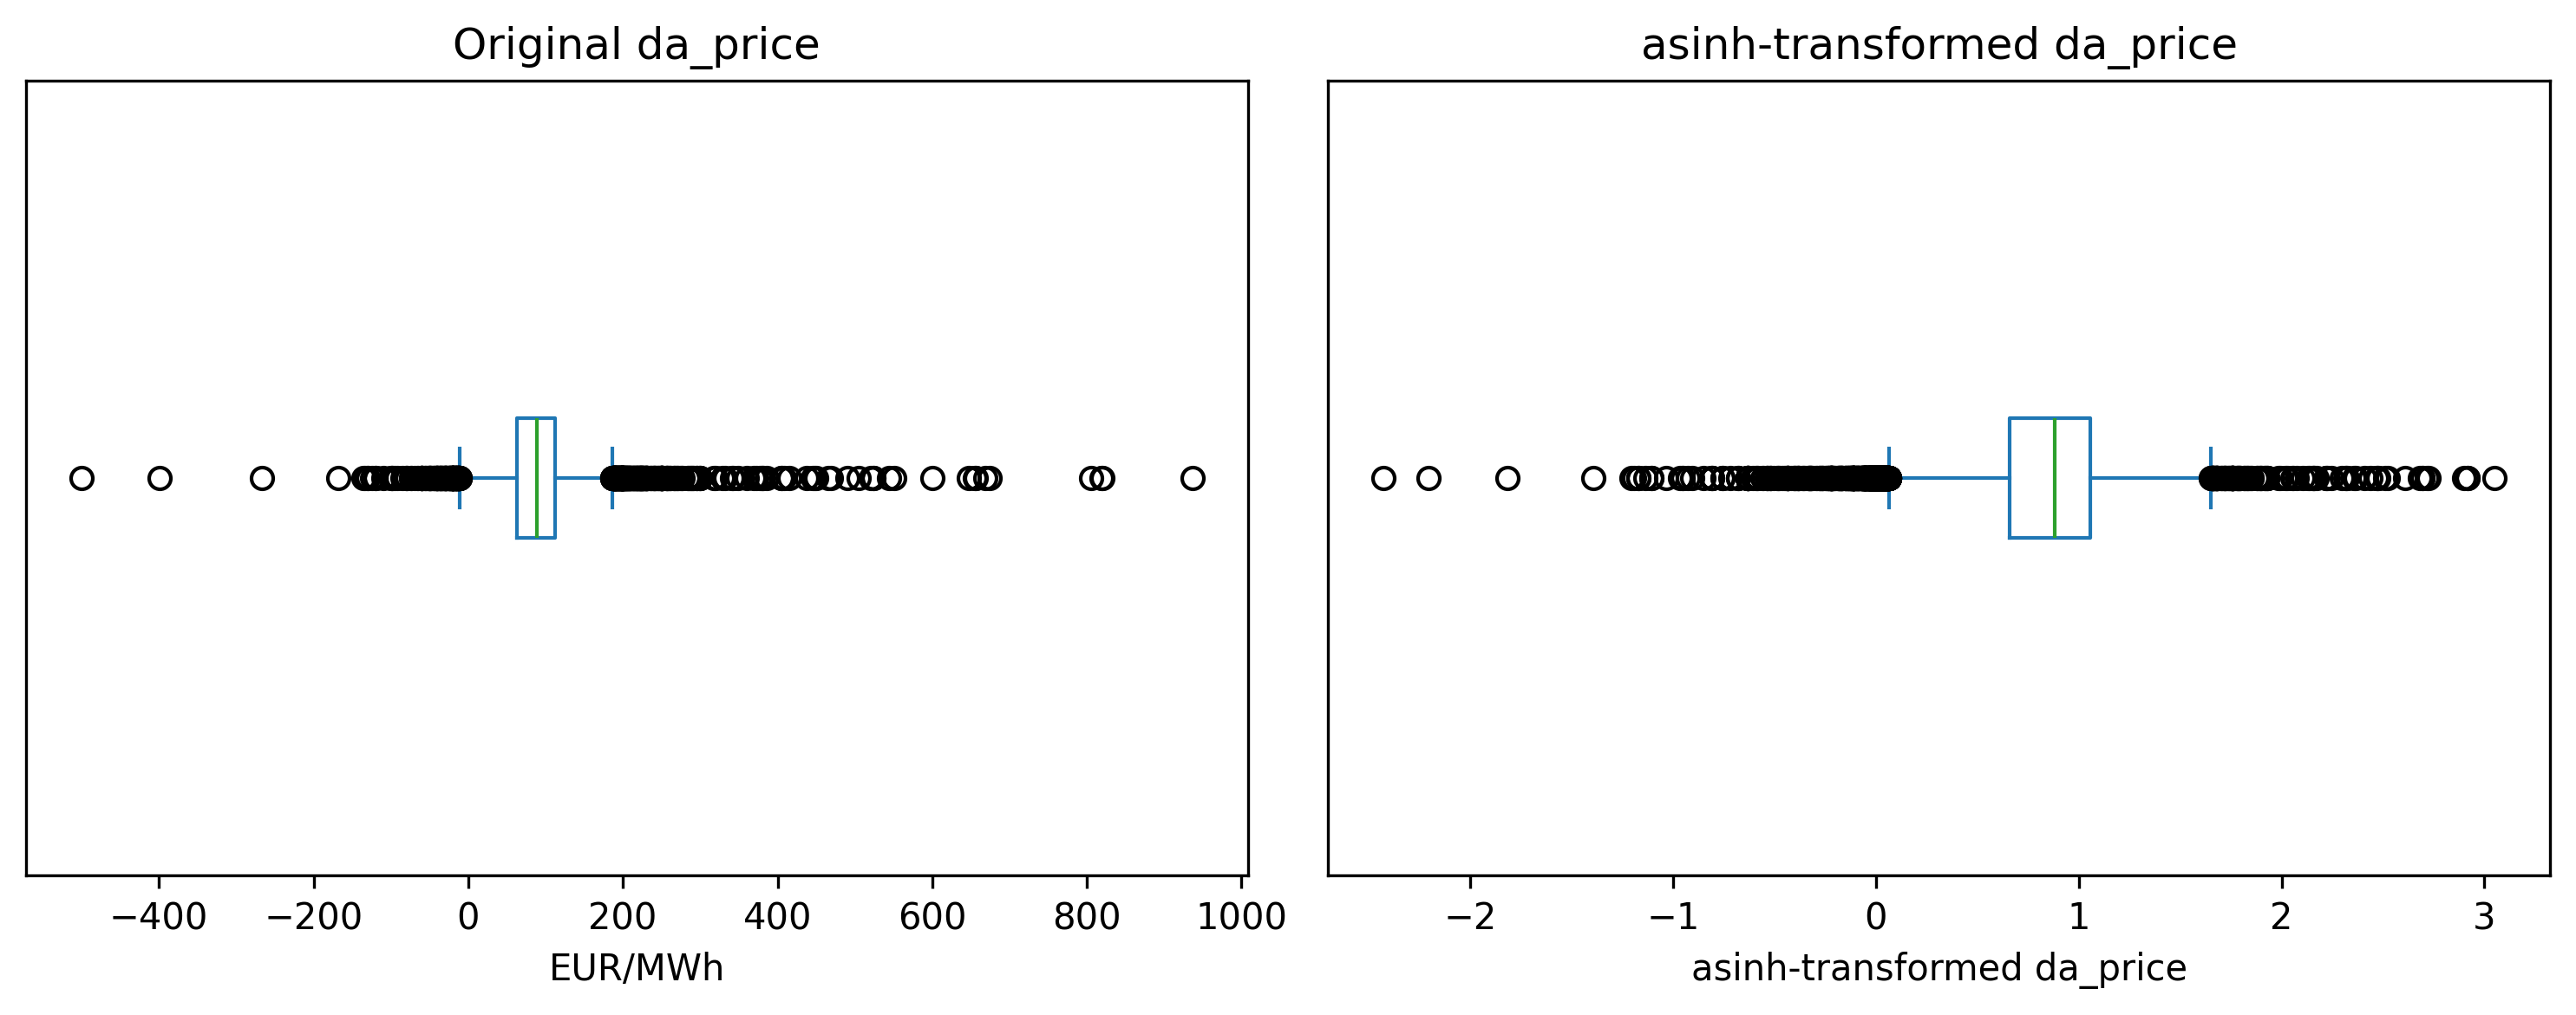

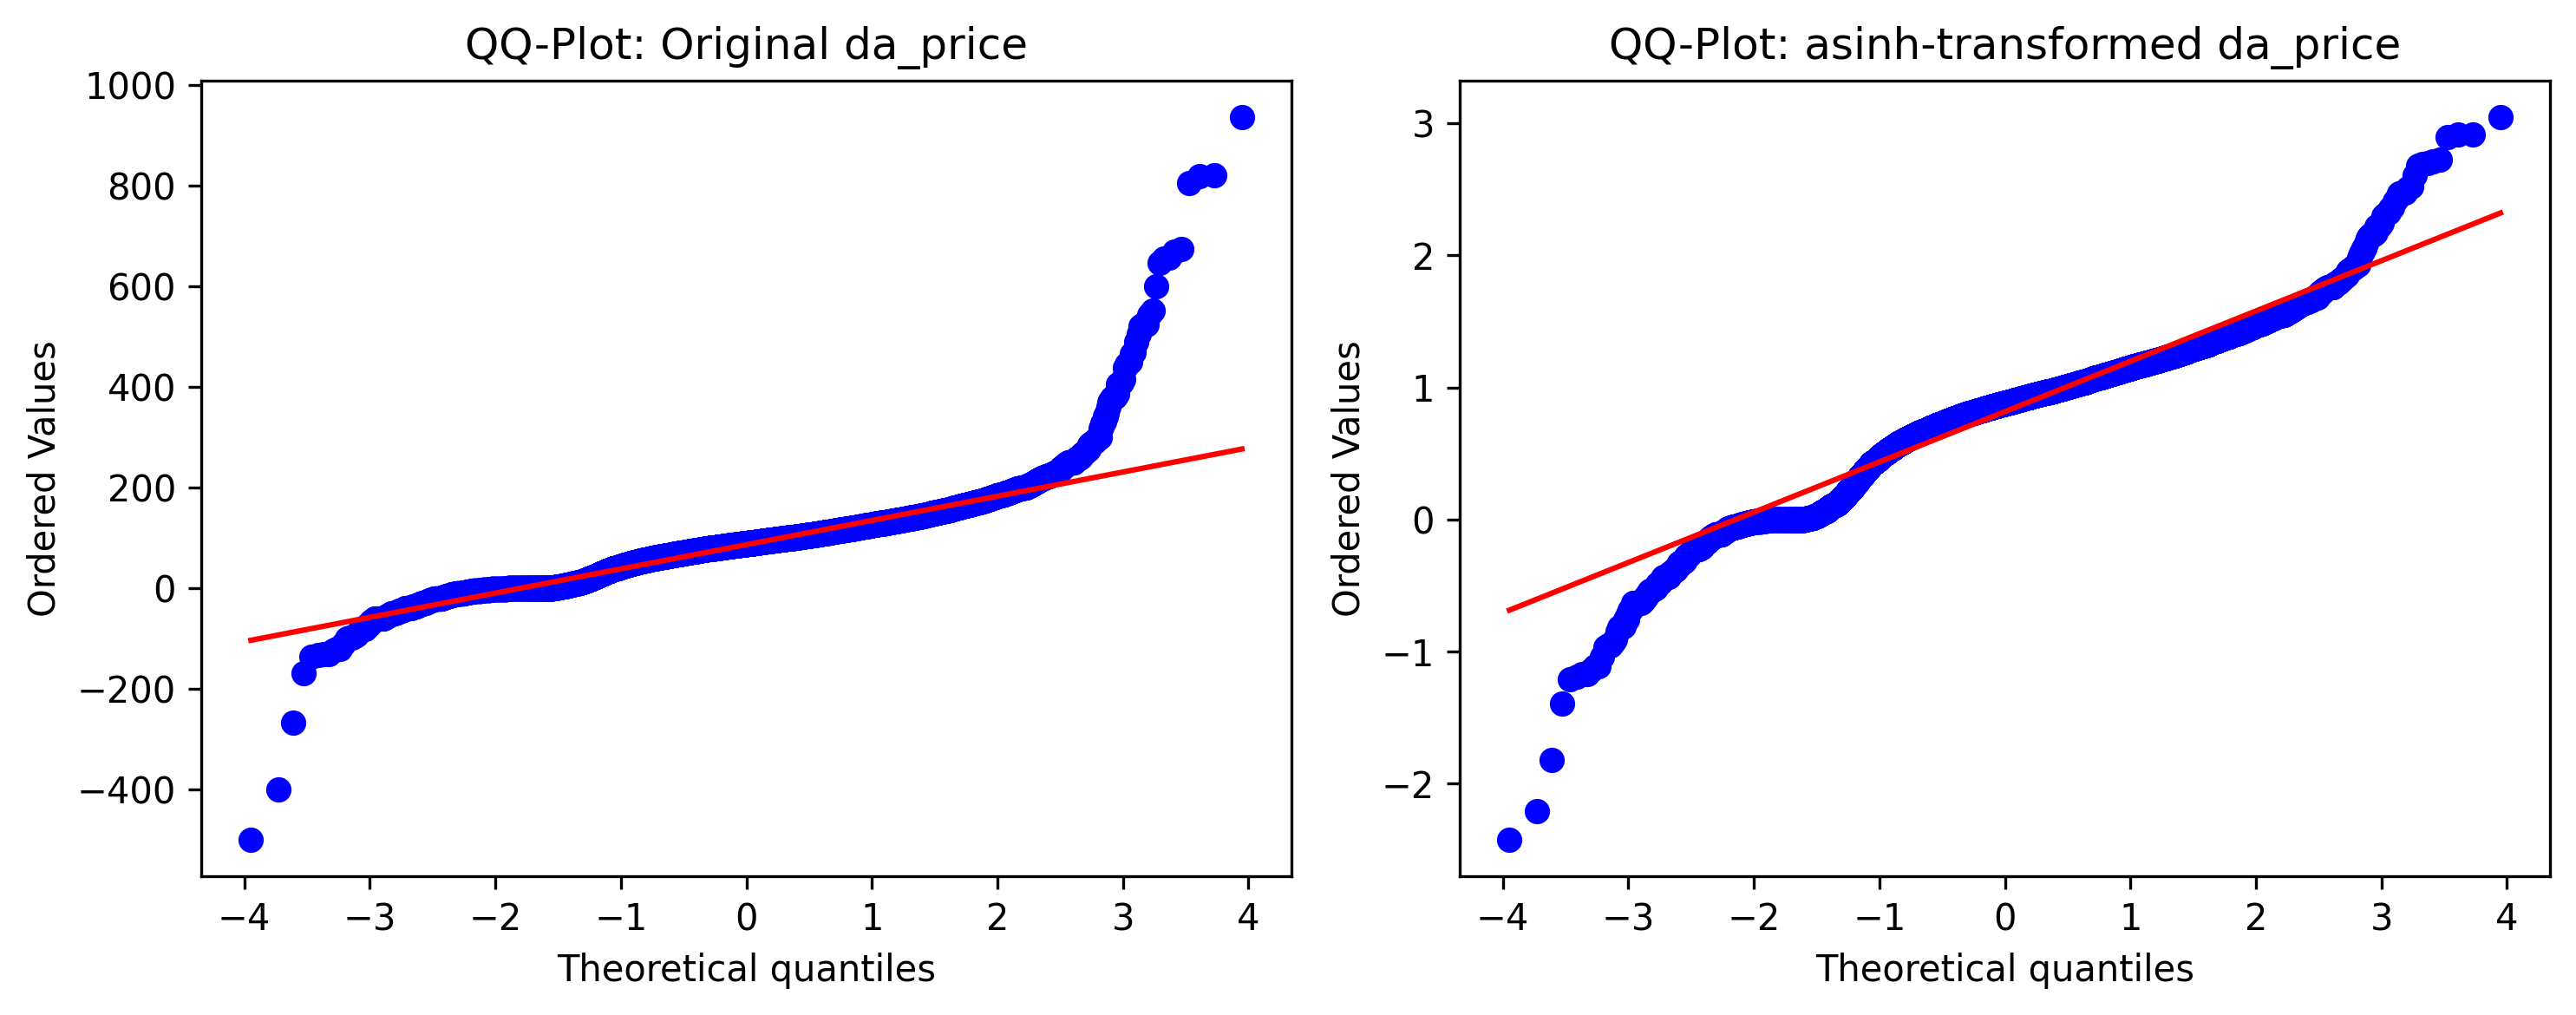

In [23]:
# asinh transformation to reduce outlier impact while preserving zero and negative values

c = np.median(np.abs(df_train["da_price"]))
transformed = np.arcsinh(df_train["da_price"] / c)

# BOXPLOT
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

df_train["da_price"].plot.box(ax=axes[0], vert=False)
axes[0].set_title("Original da_price")
axes[0].set_xlabel("EUR/MWh")
axes[0].set_yticks([])

transformed.plot.box(ax=axes[1], vert=False)
axes[1].set_title("asinh-transformed da_price")
axes[1].set_xlabel("asinh-transformed da_price")
axes[1].set_yticks([])

plt.tight_layout()


# QQ-PLOT
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)

stats.probplot(df_train["da_price"], plot=axes[0])
axes[0].set_title("QQ-Plot: Original da_price")

stats.probplot(transformed, plot=axes[1])
axes[1].set_title("QQ-Plot: asinh-transformed da_price")


plt.tight_layout()

The original price distribution has heavy tails and several extreme observations. The asinh transformation compresses these values but does not produce a normally distributed target.

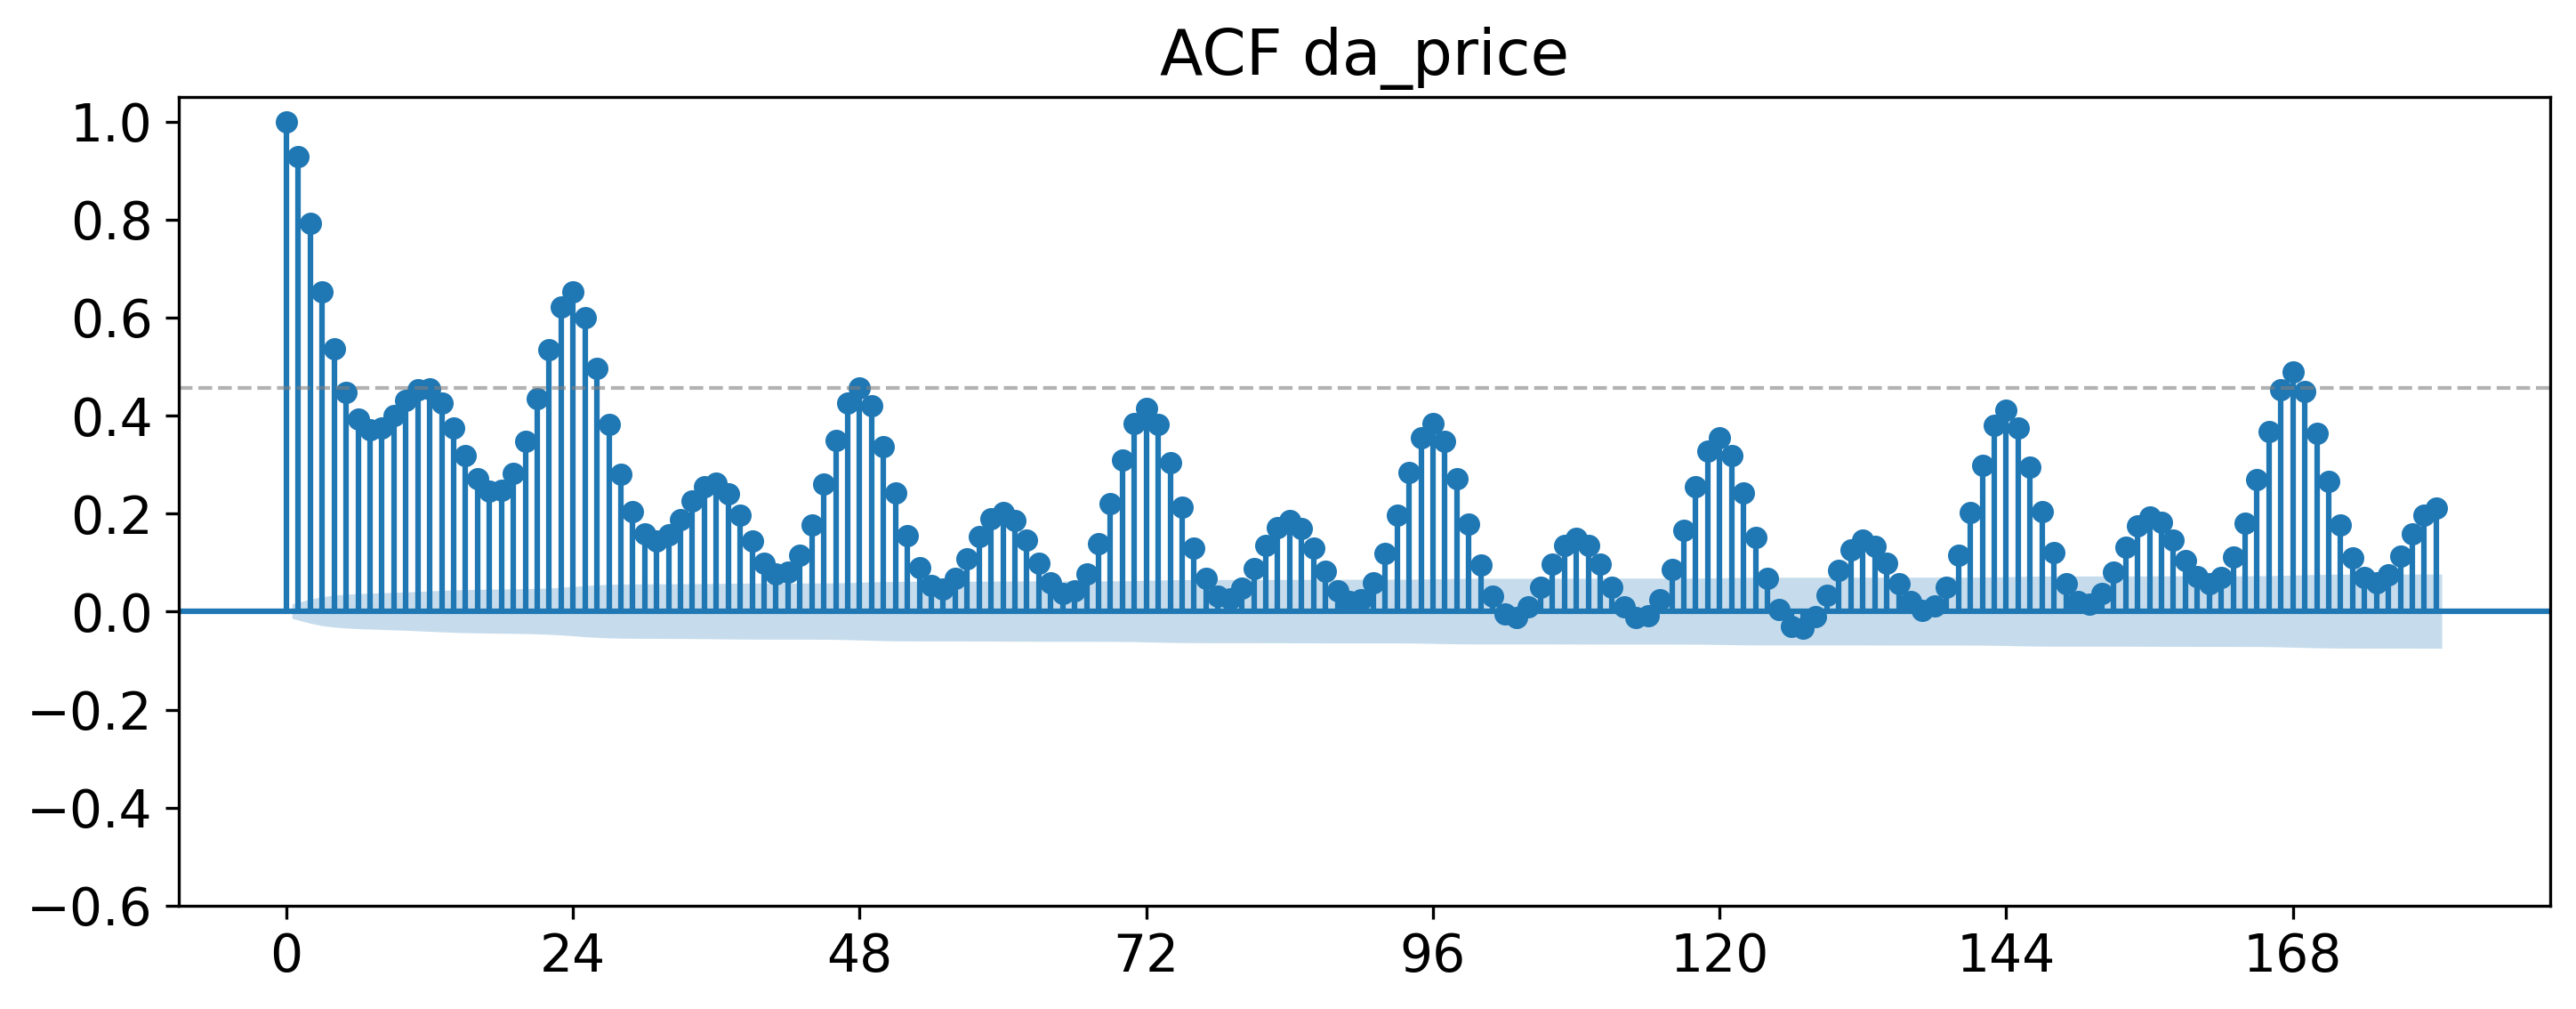

In [24]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 17,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

from statsmodels.tsa.stattools import acf

fig, ax = plt.subplots(figsize=(10, 4), dpi=300)

plot_acf(df_train["da_price"], lags=180, ax=ax, title="ACF da_price")

acf_vals = acf(df_train["da_price"], nlags=180)

ax.axhline(
    acf_vals[48],
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

ax.set_xticks(np.arange(0, 181, 24))
ax.set_ylim(-0.6, 1.05)

plt.tight_layout()

plt.rcdefaults()

The ACF has clear peaks at daily multiples. The 24-hour peak is the strongest, while the 48- and 168-hour peaks stand out slightly from the intervening daily multiples. This supports using the 24-, 48-, and 168-hour price lags.

# Insights `load_fc` and it's relation to `da_price`

In [25]:
yearly = df_train.groupby(df_train.index.year)["load_fc"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
total = df_train["load_fc"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).to_frame().T
total.index = ["all data"]

display("load_fc summary statistics:")
pd.concat([yearly, total]).round(2)

'load_fc summary statistics:'

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
2023,8760.0,53043.31,9351.33,30893.06,34699.27,38416.48,45462.11,53004.26,60313.66,68311.70,71167.75,74041.82
2024,8784.0,53154.41,8895.98,32512.34,36265.35,39580.51,45722.23,52628.82,60985.54,66844.28,69590.98,73244.92
all data,17544.0,53098.94,9126.09,30893.06,35400.70,38904.26,45603.86,52835.53,60627.93,67541.15,70703.16,74041.82


/var/folders/tx/x04j09h149n2njzlqqys6rbh0000gn/T/ipykernel_51303/2883104886.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_by_bin = transformed.groupby(binned).mean()


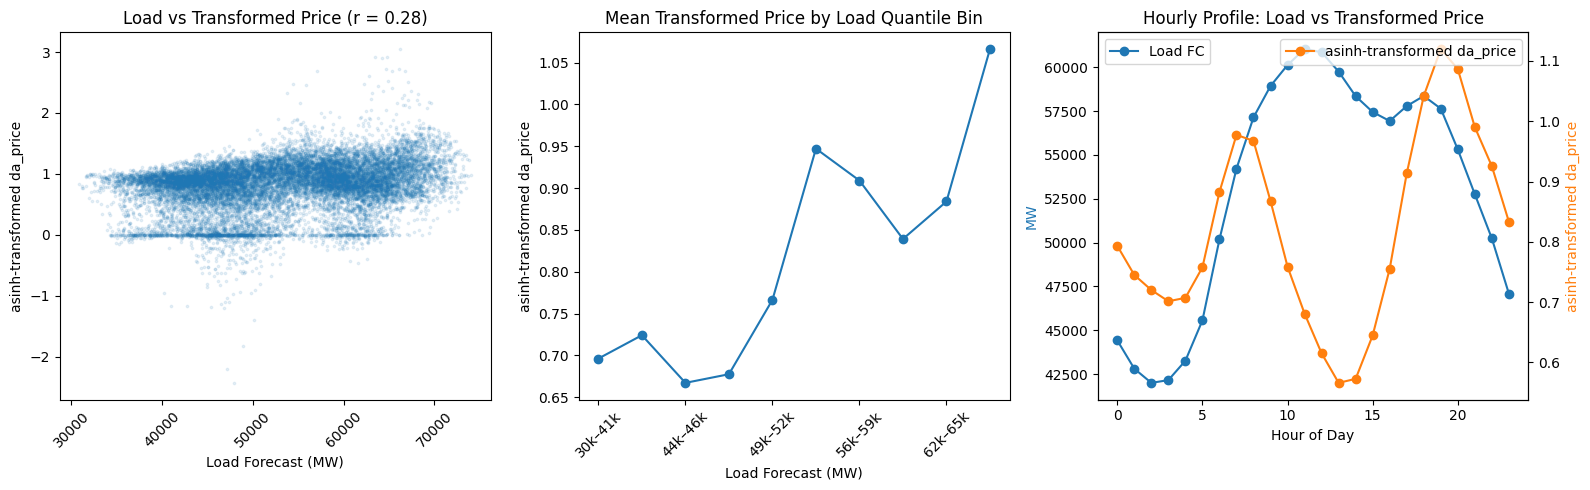

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Scatterplot load_fc vs asinh-transformed da_price
axes[0].scatter(df_train["load_fc"], transformed, alpha=0.1, s=3)
axes[0].set_xlabel("Load Forecast (MW)")
axes[0].set_ylabel("asinh-transformed da_price")
axes[0].set_title(f"Load vs Transformed Price (r = {df_train['load_fc'].corr(transformed):.2f})")
axes[0].tick_params(axis="x", rotation=45)

# 2. Quantile-Bin-Plot (non-linear relationship)
binned = pd.qcut(df_train["load_fc"], q=10, duplicates="drop")
mean_by_bin = transformed.groupby(binned).mean()
# x-axis labels: quantile boundaries (min/max of bins)
bin_labels = [f"{int(iv.left/1000)}k–{int(iv.right/1000)}k" for iv in mean_by_bin.index.categories]
mean_by_bin.index = bin_labels
mean_by_bin.plot(ax=axes[1], marker="o", title="Mean Transformed Price by Load Quantile Bin")
axes[1].set_ylabel("asinh-transformed da_price")
axes[1].set_xlabel("Load Forecast (MW)")
axes[1].tick_params(axis="x", rotation=45)

# 3. Hourly profile: load_fc vs asinh-transformed da_price (dual axis)
hourly_load = df_train.groupby(df_train.index.hour)["load_fc"].mean()
hourly_price = transformed.groupby(df_train.index.hour).mean()
ax_left = axes[2]
ax_right = ax_left.twinx()
ax_left.plot(hourly_load.index, hourly_load.values, marker="o", color="tab:blue", label="Load FC")
ax_right.plot(hourly_price.index, hourly_price.values, marker="o", color="tab:orange", label="asinh-transformed da_price")
ax_left.set_xlabel("Hour of Day")
ax_left.set_ylabel("MW", color="tab:blue")
ax_right.set_ylabel("asinh-transformed da_price", color="tab:orange")
ax_left.set_title("Hourly Profile: Load vs Transformed Price")
ax_left.legend(loc="upper left")
ax_right.legend(loc="upper right")

plt.tight_layout()

Higher load forecasts are generally associated with higher transformed prices. The relationship varies across the load range and delivery hours, so the load forecast alone does not explain the observed price pattern.

# Insights Weather Features and their relation to `da_price`

In [27]:
weather_cols = ["ssrd_fc", "tcc_fc", "t2m_fc", "rh2m_fc", "U100_fc", "sp_fc"]
weather_summary = df_train[weather_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T.round(2)
weather_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
ssrd_fc,17544.0,133.47,190.69,0.00,0.00,0.00,0.00,19.87,224.14,551.43,693.66,864.74
tcc_fc,17544.0,69.31,25.93,0.22,5.47,16.94,52.27,76.35,91.24,99.07,99.96,100.00
t2m_fc,17544.0,283.70,7.06,266.10,269.82,272.81,278.44,283.03,288.82,296.00,300.20,305.32
rh2m_fc,17544.0,78.27,12.52,29.48,43.23,51.96,71.51,81.74,87.76,92.73,95.48,97.98
U100_fc,17544.0,7.31,3.06,1.17,2.45,3.22,5.00,6.84,9.11,13.21,15.82,20.55
sp_fc,17544.0,99990.81,981.38,96174.27,97402.25,98253.99,99405.18,100055.62,100649.99,101540.93,102120.07,102520.89


### Correlation with da_price

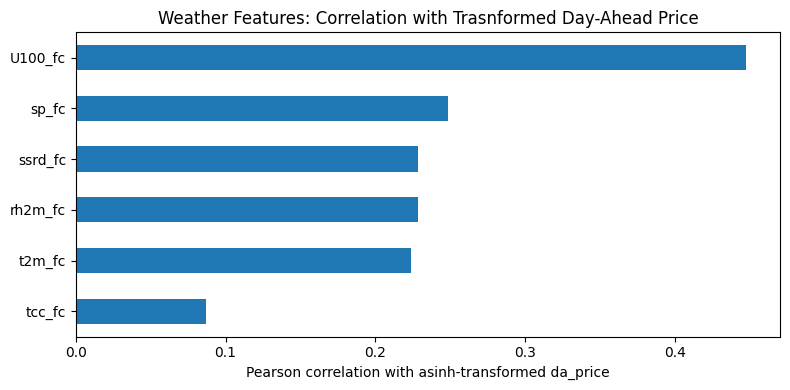

In [28]:
corr_with_price = df_train[weather_cols].corrwith(transformed).abs().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
corr_with_price.plot.barh(ax=ax)
ax.set_xlabel("Pearson correlation with asinh-transformed da_price")
ax.set_title("Weather Features: Correlation with Trasnformed Day-Ahead Price")
ax.axvline(0, color="black", linewidth=0.5)
plt.tight_layout()

### Multicolliniarity check (Correlationmatrix)

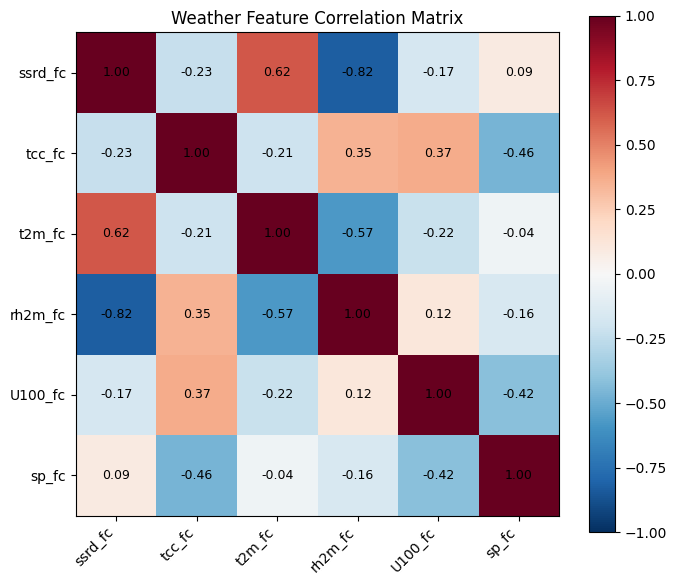

In [29]:
fig, ax = plt.subplots(figsize=(7, 6))
corr_matrix = df_train[weather_cols].corr()
im = ax.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(weather_cols)))
ax.set_yticks(range(len(weather_cols)))
ax.set_xticklabels(weather_cols, rotation=45, ha="right")
ax.set_yticklabels(weather_cols)

# Annotate with values
for i in range(len(weather_cols)):
    for j in range(len(weather_cols)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax)
ax.set_title("Weather Feature Correlation Matrix")
plt.tight_layout()

*ssrd_fc*, *t2m_fc*, and *rh2m_fc* are strongly correlated. *U100_fc* and *sp_fc* are also correlated. These associations do not by themselves determine which variables should be retained.

### Scatterplot of top 3 weather features of highest correlation with price

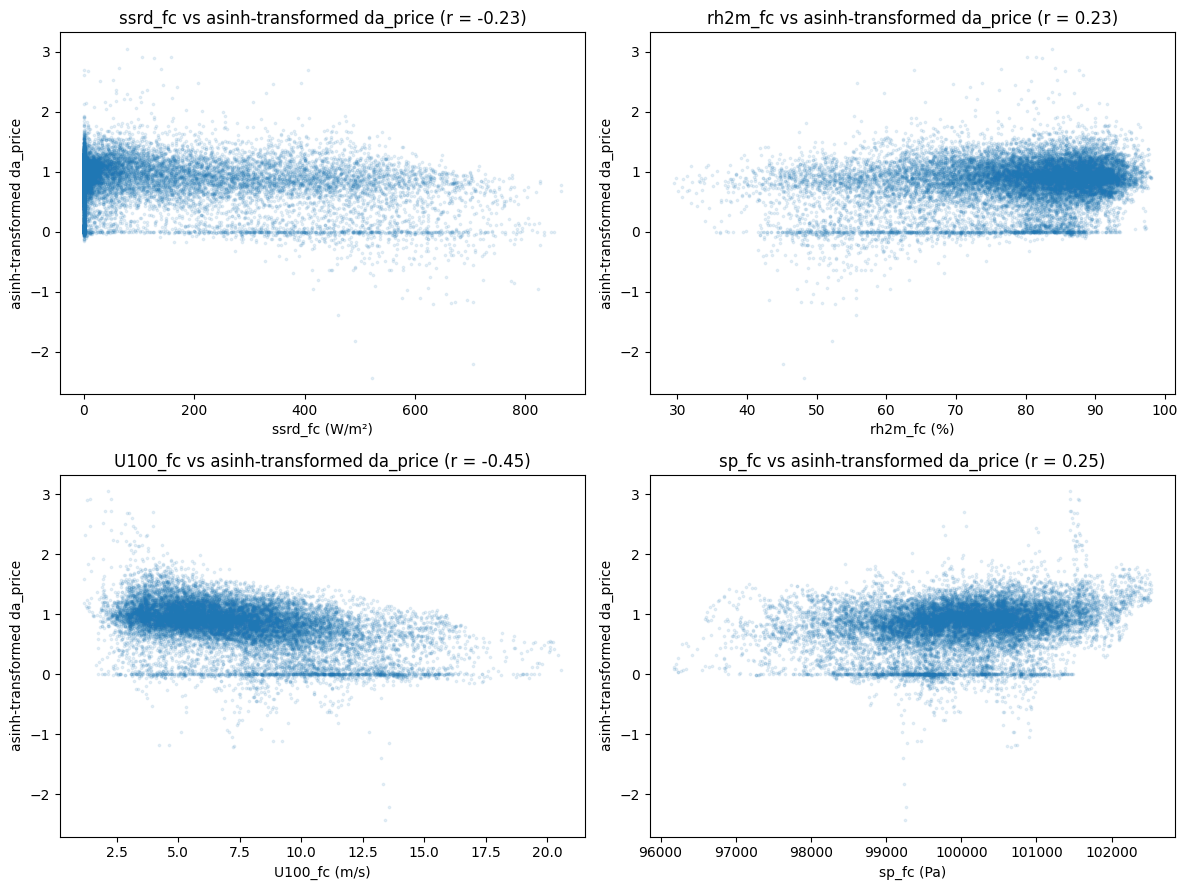

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
units = {"ssrd_fc": "W/m²", "rh2m_fc": "%", "U100_fc": "m/s", "sp_fc": "Pa"}

for ax, col in zip(axes.flat, ["ssrd_fc", "rh2m_fc", "U100_fc", "sp_fc"]):
    ax.scatter(df_train[col], transformed, alpha=0.1, s=3)
    ax.set_xlabel(f"{col} ({units.get(col, '')})")
    ax.set_ylabel("asinh-transformed da_price")
    r = df_train[col].corr(transformed)
    ax.set_title(f"{col} vs asinh-transformed da_price (r = {r:.2f})")

plt.tight_layout()

*U100_fc* has the strongest bivariate association with the transformed price among the weather variables shown here. Several solar-related variables are strongly correlated. These diagnostics are exploratory; the final weather features are selected by recursive elimination in the modelling notebook.